[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/allison-diebol/open-iris/blob/main/colab/EvaluationSuiteDemo.ipynb)

# Evaluation Suite Demo

This notebook demonstrates how to use the **easy-to-use evaluation functions** for the open-iris pipeline. These helper functions abstract away the complexity of the full pipeline and allow for quick dataset experimentation and evaluation. It also helps to integrate the newer evaluation metrics with the evaluation tools provided in `IRISVisualizer`.

### Import Libraries

We begin by importing standard Python libraries for file handling and randomness, along with the **evaluation utilities** from the open-iris package.

The key functions used in this notebook are:

**Evaluation Suite**
- `evaluate_dataset`: Runs the full pipeline (template creation, matching, scoring)
- `evaluation_report`: Prints a summary of performance metrics
- `plot_roc`: Visualizes the ROC curve
- `plot_far_frr`: Shows FAR vs FRR tradeoff
- `plot_score_distributions`: Displays genuine vs impostor score distributions

**`iris.utils.visualisation`**
- `IRISVisualizer`: A class with methods to visualize pipeline intermediate outputs (IR images, segmentation maps, geometry polygons, normalized iris, iris templates, and more)

  
These functions are designed to simplify the evaluation process into just a few lines of code.

In [2]:
import sys
import os
import random
import shutil
from pathlib import Path

import cv2
import iris
import matplotlib.pyplot as plt

from iris.evaluation.evaluation_metrics import evaluate_dataset, evaluation_report, plot_roc, plot_far_frr, plot_score_distributions
from iris.utils.visualisation import IRISVisualizer

## Evaluation with `iris.evaluation.evaluation_metrics`

### Prepare a Sample Dataset

The full dataset can be quite large, so we randomly sample a subset of images to make experimentation faster.

Steps performed here:
- Traverse the dataset directory
- Collect all available iris images
- Randomly select a subset (e.g., 500 images)
- Copy them into a temporary folder (`./sample_imgs`)

This sampled dataset will be used for evaluation in the next steps. Replace `src_root` with your folder of iris images.

In [11]:
src_root = Path("data-folder")

# Temp folder to hold sampled images
dst_root = Path("./sample_imgs")
dst_root.mkdir(exist_ok=True)

all_images = []
for subject_dir in src_root.iterdir():
    if not subject_dir.is_dir():
        continue
    for eye in ["L", "R"]:
        eye_dir = subject_dir / eye
        if eye_dir.exists():
            for img in eye_dir.glob("*.jpg"):
                all_images.append((subject_dir.name, eye, img))

print(f"Total images found: {len(all_images)}")

left_images = [x for x in all_images if x[1] == "L"]
sampled = random.sample(left_images, 500)

for i, (subject, eye, img_path) in enumerate(sampled):
    new_name = f"{subject}_{eye}_{i:04d}.jpg"
    shutil.copy(img_path, dst_root / new_name)

print(f"Copied {len(sampled)} images to {dst_root}")

Total images found: 20000
Copied 500 images to sample_imgs


The output confirms:
- Total number of images found in the dataset
- Number of images copied into the sample folder

This ensures we are working with a manageable subset while preserving dataset diversity.

### Run the Evaluation Pipeline

We now run the full evaluation pipeline using a single function call:

```python
result = evaluate_dataset(...)
```
It internally processes each image to generate a biometric template, generates genuine and imposter pairs, and computes the similarity scores.

In [12]:
result = evaluate_dataset(
    "./sample_imgs",
    eye_side="left",
    verbose=True
)

evaluation_report(result);


Loading templates from: ./sample_imgs
[40.0%] Processed 200/500 → OK: 180, SKIP: 20
[60.0%] Processed 300/500 → OK: 272, SKIP: 28
[80.0%] Processed 400/500 → OK: 371, SKIP: 29
[100.0%] Processed 500/500 → OK: 465, SKIP: 35

Finished processing 500 images
OK: 465
SKIP: 35

Building pairs from 465 templates …
    Genuine pairs : 104
    Impostor pairs: 107776

Computing match scores …
════════════════════════════════════════════════════
  open-iris  |  Evaluation Report
════════════════════════════════════════════════════
  Genuine comparisons : 104
  Impostor comparisons: 107,776

  EER                 : 8.634 %
  EER threshold       : 0.45430
  AUC (ROC)           : 0.93131

  Operating points:
    FAR=0.1%  →  FRR=13.46%  (threshold=0.4155)
    FAR=1.0%  →  FRR=10.58%  (threshold=0.4335)
    FAR=10.0%  →  FRR=8.65%  (threshold=0.4562)
════════════════════════════════════════════════════


During execution, the pipeline provides progress updates:

- **OK**: Successfully processed images  
- **SKIP**: Images that failed processing  
- **Progress %**: Indicates how much of the dataset has been processed  

After processing:
- Templates are used to generate genuine and impostor pairs
- Match scores are computed for all comparisons

This gives insight into both **data quality** and **pipeline robustness**.

### Evaluation Report

We now summarize the performance using:

```python
evaluation_report(result)
```
This report includes:
- Genuines comparisons
- Imposter comparisons
- Equal Error Rate (EER)
- Area Under the Curve (AUC)
- Performance at specific False Accept Rate (FAR) thresholds

### Key Takeaways

- A lower **EER** indicates better performance  
- A higher **AUC** (closer to 1) indicates stronger separation between classes  
- The imbalance between impostor and genuine pairs is expected due to combinatorics

This report provides a quick, high-level understanding of system effectiveness.

### ROC Curve

The ROC (Receiver Operating Characteristic) curve visualizes the tradeoff between:

- **False Accept Rate (FAR)**
- **True Accept Rate (TAR)**

A curve closer to the top-left corner indicates better performance.

This plot helps us understand how well the system separates genuine and impostor matches across thresholds.

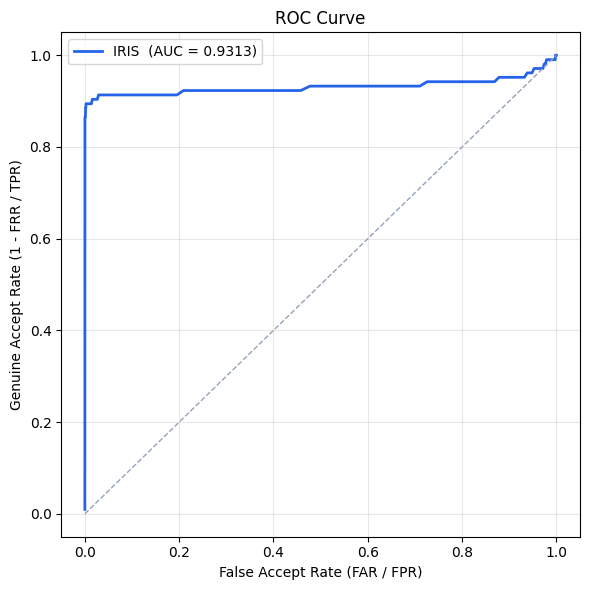

In [15]:
plot_roc(result);

### FAR vs FRR Curve

This plot shows the relationship between:

- **FAR (False Accept Rate)**
- **FRR (False Reject Rate)**

The intersection point corresponds to the **Equal Error Rate (EER)**.

This visualization is especially useful for selecting an appropriate decision threshold depending on application requirements.

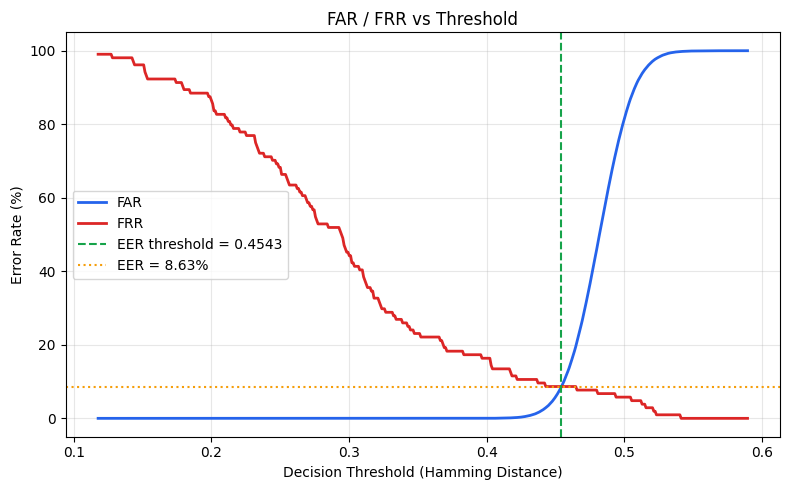

In [16]:
plot_far_frr(result);

### Score Distributions

This plot shows the distribution of similarity scores for:

- Genuine pairs (same subject)
- Impostor pairs (different subjects)

Ideal behavior:
- Genuine scores are tightly grouped and high
- Impostor scores are lower and well separated

Overlap between the two distributions indicates potential classification errors.

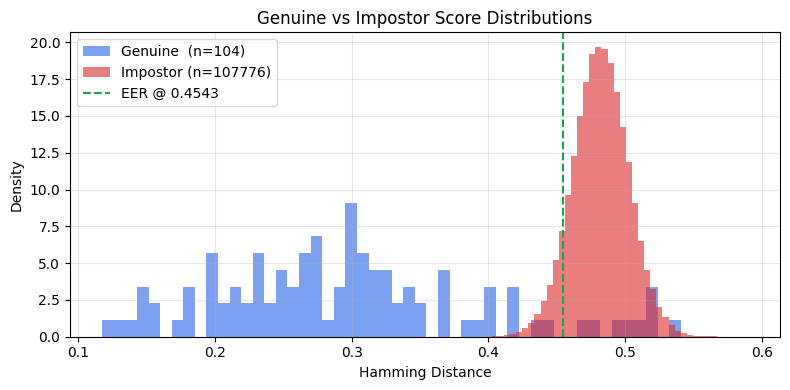

In [18]:
plot_score_distributions(result);

In [19]:
evaluation_report(result);

════════════════════════════════════════════════════
  open-iris  |  Evaluation Report
════════════════════════════════════════════════════
  Genuine comparisons : 104
  Impostor comparisons: 107,776

  EER                 : 8.634 %
  EER threshold       : 0.45430
  AUC (ROC)           : 0.93131

  Operating points:
    FAR=0.1%  →  FRR=13.46%  (threshold=0.4155)
    FAR=1.0%  →  FRR=10.58%  (threshold=0.4335)
    FAR=10.0%  →  FRR=8.65%  (threshold=0.4562)
════════════════════════════════════════════════════


---

## Pipeline Evaluation with `iris.utils.visualisation`

The `iris.utils.visualisation` module provides `IRISVisualizer`, a class with methods to render every major intermediate output from the iris recognition pipeline.

This section demonstrates how to:
1. Run the IRIS pipeline on a single sample image
2. Use `IRISVisualizer` to inspect the pipeline at each stage
3. Tie those visualizations back to the evaluation results above

**Reference:** [`iris.utils.visualisation` API docs](https://worldcoin.github.io/open-iris/_code_subpages/iris.utils.html#module-iris.utils.visualisation)




In [28]:
# Assuming you have downloaded the sample image
img_path = Path("sample_ir_image.png")

img_pixels = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)

ir_image_obj = iris.IRImage(img_data=img_pixels, image_id="sample", eye_side="left")

# Run the full IRIS pipeline on this single image
pipeline = iris.IRISPipeline(env=iris.IRISPipeline.DEBUGGING_ENVIRONMENT)
output = pipeline(ir_image_obj)

In [29]:
# Pull intermediate outputs from call_trace by node name.
# These key names match what the other internal notebooks use (e.g. 01_segmentation.ipynb).
# If a key returns None, check the printed list above for the exact name on your version.
segmap        = pipeline.call_trace.get("segmentation")
geometry      = pipeline.call_trace.get("geometry_estimation")
geometry_mask = pipeline.call_trace.get("geometry_mask")
noise_mask    = pipeline.call_trace.get("noise_masks_aggregation")
eye_orient    = pipeline.call_trace.get("eye_orientation")
eye_centers   = pipeline.call_trace.get("eye_centers_estimation")
norm_iris     = pipeline.call_trace.get("normalization")
iris_response = pipeline.call_trace.get("filter_bank")
iris_template = output.get("iris_template") if isinstance(output, dict) else output.iris_template

print("segmap:       ", type(segmap))
print("geometry:     ", type(geometry))
print("geometry_mask:", type(geometry_mask))
print("noise_mask:   ", type(noise_mask))
print("eye_orient:   ", type(eye_orient))
print("eye_centers:  ", type(eye_centers))
print("norm_iris:    ", type(norm_iris))
print("iris_response:", type(iris_response))
print("iris_template:", type(iris_template))

# IRISVisualizer instance — reused for all plots below
vis = IRISVisualizer()

segmap:        <class 'iris.io.dataclasses.SegmentationMap'>
geometry:      <class 'iris.io.dataclasses.GeometryPolygons'>
geometry_mask: <class 'NoneType'>
noise_mask:    <class 'iris.io.dataclasses.NoiseMask'>
eye_orient:    <class 'iris.io.dataclasses.EyeOrientation'>
eye_centers:   <class 'NoneType'>
norm_iris:     <class 'iris.io.dataclasses.NormalizedIris'>
iris_response: <class 'iris.io.dataclasses.IrisFilterResponse'>
iris_template: <class 'iris.io.dataclasses.IrisTemplate'>


### 1. Raw IR Image

`IRISVisualizer.plot_ir_image(ir_image` renders the raw infrared intput image as the pipeline recieves it. This is the starting point for all downstream processing.

Use this to verify that the image loaded correctly and has the expected quality (contrast, focus, framing).

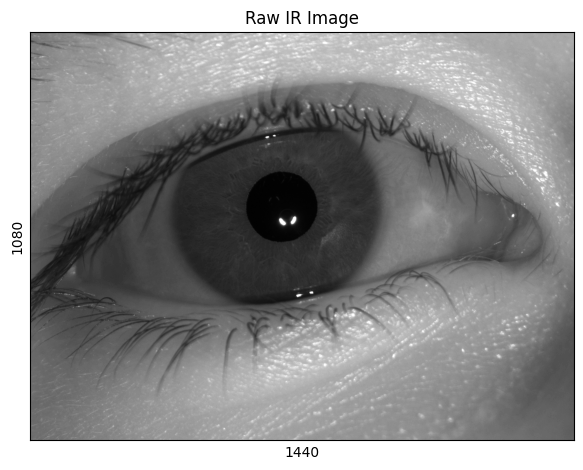

In [59]:
# plot_ir_image: renders the raw IR input image
# Signature: plot_ir_image(ir_image, ax=None) -> Tuple[Figure, Axes]
fig, ax = vis.plot_ir_image(ir_image_obj)
ax.set_title("Raw IR Image")
plt.tight_layout()

### 2. Segmentation Map

`IRISVisualizer.plot_segmentation_map(segmap, ir_image)` overlays the segmentation map (pupil, iris, eyelid predictions on the raw IR image.

This is the output of the `MultilabelSegmentation` node. Poor segmentation here propogates error through all downstream steps and will degrade EER/AUC scores seen above.

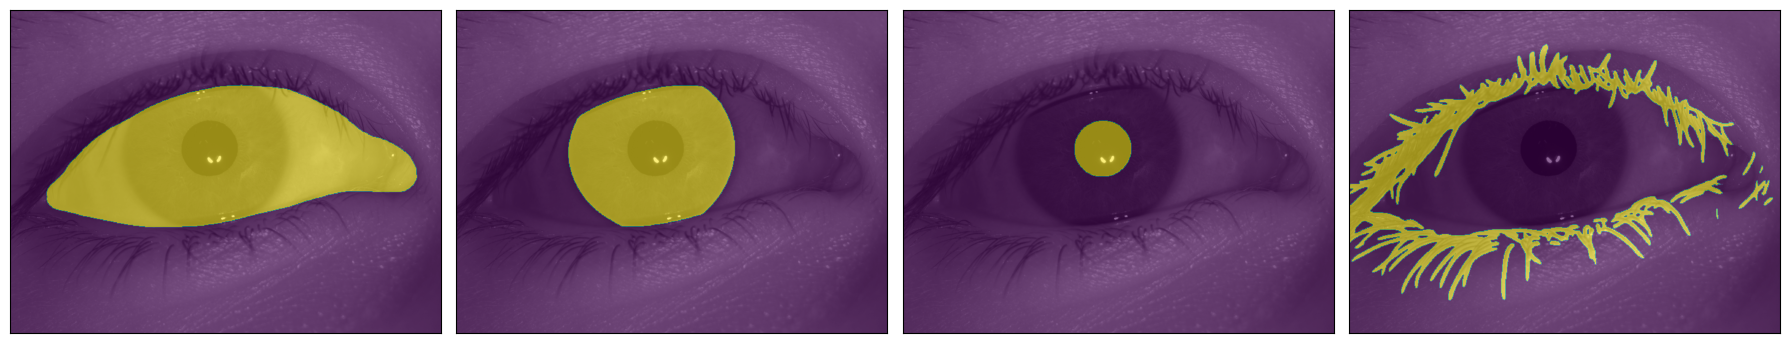

In [60]:
# plot_segmentation_map: overlays predicted segmentation regions on the IR image
# Signature: plot_segmentation_map(segmap, ir_image=None, ax=None) -> Tuple[Figure, Axes]
if segmap is not None:
    fig, ax = vis.plot_segmentation_map(segmap, ir_image=ir_image_obj)
    plt.tight_layout()
else:
    print("No segmentation_map in output")

### 3. Geometry Polygons

`IRISVisualizer.plot_geometry_polygons(geometry_polygons, ir_image)` draws the fitted pupil and iris boundary polygons over the IR image.

These polygons are produced by the geometry estimation nodes (e.g., `MomentOfArea`, `BisectorsMethod`, ellipse fitting). Poorly fitted polygons lead to incorrect normalization and degraded iris templates.

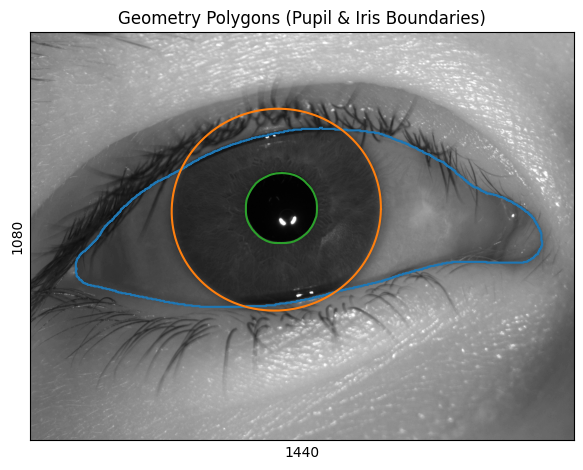

In [61]:
# plot_geometry_polygons: draws pupil/iris boundary polygons
# Signature: plot_geometry_polygons(geometry_polygons, ir_image=None,
#            plot_kwargs=None, scatter_kwargs=None, ax=None) -> Tuple[Figure, Axes]
if geometry is not None:
    fig, ax = vis.plot_geometry_polygons(geometry, ir_image=ir_image_obj)
    ax.set_title("Geometry Polygons (Pupil & Iris Boundaries)")
    plt.tight_layout()
else:
    print("'geometry_estimation' not found in call_trace — check key names printed above")

### 4. Eye Centers & Orientation

`IRISVisualizer.plot_all_geometry(ir_image, geometry_polygons, eye_orientation, eye_center)` combines the IR image, geometry polygons, estimated pupil/iris center points, and the eye orientation angle into a single diagnostic plot.

This is the most comprehensive single-image visualization — useful for spotting systematic mis-registration in images that score poorly in the evaluation.

In [62]:
# plot_all_geometry: combined view of polygons, eye centers, and orientation
# Signature: plot_all_geometry(ir_image, geometry_polygons,
#            eye_orientation, eye_center) -> Tuple[Figure, Axes]
import numpy as np
mask = np.zeros(ir_image_obj.img_data.shape, dtype=np.uint8)
cv2.fillPoly(mask, [geometry.iris_array.astype(np.int32)], 255)

if geometry is not None and eye_orient is not None and eye_centers is not None:
    fig, axes = vis.plot_all_geometry(ir_image, geometry, eye_orient, eye_centers)
    fig.suptitle("Full Geometry Overview", fontsize=13)
    plt.tight_layout()

else:
    print("One or more geometry inputs not found in call_trace — check key names printed above")

One or more geometry inputs not found in call_trace — check key names printed above


### 5. Geometry Mask

`IRISVisualizer.plot_geometry_mask(geometry_mask, ir_image)` shows the binary mask derived from the geometry polygons — the region considered valid iris texture for normalization.

A mask with occlusions (eyelids, reflections) reduces the usable iris area and can increase the FRR for affected subjects.

In [63]:
# plot_geometry_mask: binary mask of the valid iris region
# Signature: plot_geometry_mask(geometry_mask, ir_image=None, ax=None) -> Tuple[Figure, Axes]
if geometry_mask is not None:
    fig, ax = vis.plot_geometry_mask(geometry_mask, ir_image=ir_image)
    ax.set_title("Geometry Mask (Valid Iris Region)")
    plt.tight_layout()
else:
    print("'geometry_mask' not found in call_trace — check key names printed above")

'geometry_mask' not found in call_trace — check key names printed above


### 6. Noise Mask

`IRISVisualizer.plot_noise_mask(noise_mask, ir_image)` shows which parts of the normalized iris are flagged as unreliable due to noise (eyelashes, specular reflections, eyelid occlusion).

Noisy bits are excluded during template matching. High noise mask coverage reduces the effective iris code length and can inflate EER.

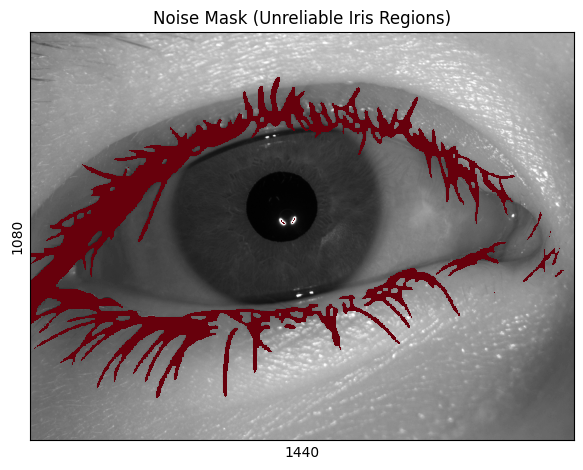

In [64]:
# plot_noise_mask: highlights unreliable (noisy) regions in the iris
# Signature: plot_noise_mask(noise_mask, ir_image=None, ax=None) -> Tuple[Figure, Axes]
if noise_mask is not None:
    fig, ax = vis.plot_noise_mask(noise_mask, ir_image=ir_image_obj)
    ax.set_title("Noise Mask (Unreliable Iris Regions)")
    plt.tight_layout()
else:
    print("'noise_masks_aggregation' not found in call_trace — check key names printed above")

### 7. Normalized Iris

`IRISVisualizer.plot_normalized_iris(normalized_iris)` renders the iris texture after it has been "unrolled" from polar to Cartesian coordinates (Daugman's rubber sheet model).

This is the representation that Gabor filters are applied to during encoding. The texture should appear as a horizontal band of distinct patterns. Blurry or washed-out textures here tend to produce low-quality iris codes.

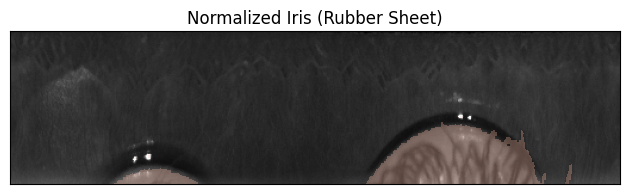

In [65]:
# plot_normalized_iris: the unrolled iris texture (rubber sheet model output)
# Signature: plot_normalized_iris(normalized_iris, plot_mask=True,
#            stretch_hist=True, exposure_factor=1.0, ax=None) -> Tuple[Figure, Axes]
if norm_iris is not None:
    fig, ax = vis.plot_normalized_iris(norm_iris, plot_mask=True, stretch_hist=True, exposure_factor=1.0)
    ax.set_title("Normalized Iris (Rubber Sheet)")
    plt.tight_layout()
else:
    print("'normalization' not found in call_trace — check key names printed above")

### 8. Iris Filter Response

`IRISVisualizer.plot_iris_filter_response(iris_filter_response)` shows the real, imaginary, and amplitude responses of the Gabor filter bank applied to the normalized iris.

The filter response is the intermediate signal that gets binarized into the final iris code. Strong, well-structured responses indicate high-quality encoding. The `space` parameter lets you view responses in Cartesian or polar coordinates.

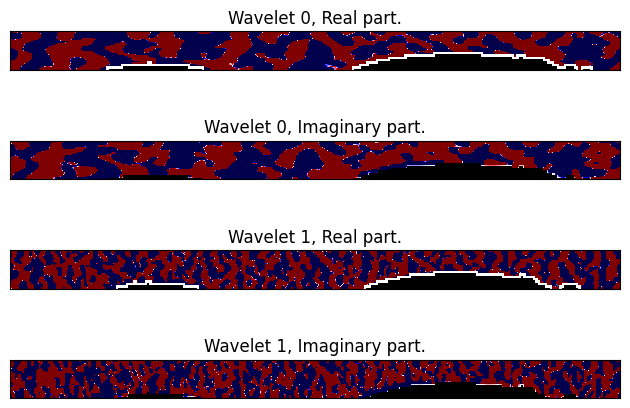

In [66]:
# plot_iris_filter_response: Gabor filter response (real, imaginary, amplitude)
# Signature: plot_iris_filter_response(iris_filter_response, space='cartesian',
#            plot_mask=True, mask_threshold=0.93, vlim=0.001, ax=None) -> Tuple[Figure, Axes]
if iris_response is not None:
    fig, axes = vis.plot_iris_filter_response(iris_response, space="cartesian", plot_mask=True, mask_threshold=0.93)
    plt.tight_layout()
else:
    print("'filter_bank' not found in call_trace — check key names printed above")

### 9. Iris Template

`IRISVisualizer.plot_iris_template(iris_template)` displays the final binarized iris code and its mask.

Each bit encodes the phase of the Gabor filter response at a particular location. Two iris codes are compared via a masked Hamming distance — the metric underpinning all scores in the evaluation suite above. A template with a very high proportion of masked bits (shown in gray) will be a weaker biometric.

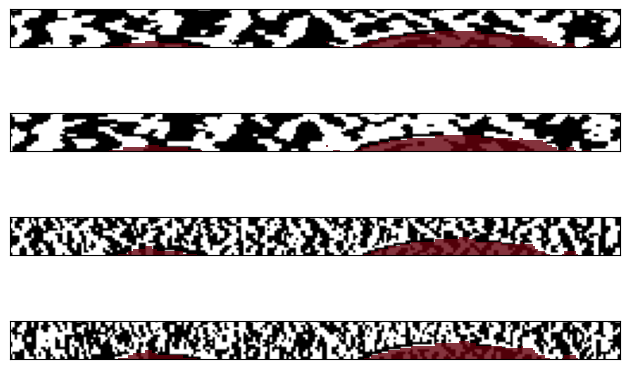

In [67]:
# plot_iris_template: the final binarized iris code and its mask
# Signature: plot_iris_template(iris_template, plot_mask=True, ax=None) -> Tuple[Figure, Axes]
if iris_template is not None:
    fig, ax = vis.plot_iris_template(iris_template, plot_mask=True)
    plt.tight_layout()
else:
    print("iris_template not found in output")

### 10. Iris Template + Normalized Iris (Overlay)

`IRISVisualizer.plot_iris_template_and_normalized_iris(iris_template, normalized_iris)` overlays the iris code on the normalized iris texture, making it easy to see how the Gabor phase encodings relate to the underlying texture patterns.

This is particularly useful for understanding which texture features are driving the matching score.

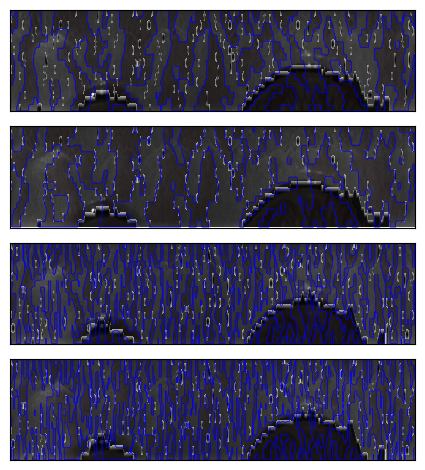

In [68]:
# plot_iris_template_and_normalized_iris: overlay iris code on normalized texture
# Signature: plot_iris_template_and_normalized_iris(iris_template, normalized_iris,
#            plot_mask=True, linewidth=0.5, fill_alpha=0.05, ax=None) -> Tuple[Figure, Axes]
if iris_template is not None and norm_iris is not None:
    fig, ax = vis.plot_iris_template_and_normalized_iris(iris_template, norm_iris, plot_mask=True, linewidth=0.5, fill_alpha=0.05)
    plt.tight_layout()
else:
    print("iris_template or normalization not available")


## Summary

In this notebook, we demonstrated how to:

- Quickly evaluate an iris dataset using high-level helper functions
- Generate meaningful biometric metrics with minimal code
- Visualize system performance through standard plots (ROC, FAR/FRR, score distributions)
- Access intermediate pipeline outputs via `pipeline.call_trace` using `IRISPipeline.DEBUGGING_ENVIRONMENT`
- Inspect each pipeline stage using `IRISVisualizer` from `iris.utils.visualisation`:
  - Raw IR image → Segmentation map → Geometry polygons → Full geometry overview
  - Geometry mask → Noise mask → Normalized iris → Gabor filter response → Iris template

These utilities make it easy to experiment with different datasets, preprocessing choices, and evaluation settings without needing to manually implement the full pipeline.

**API Reference:** [iris.utils.visualisation](https://worldcoin.github.io/open-iris/_code_subpages/iris.utils.html#module-iris.utils.visualisation)